## cifar10 and fab norm

In [12]:
import pandas
import os

print(os.getcwd())
df = pandas.read_csv("results/resnet20_checkpoint_evaluations.csv")


/home/vilmos/Documents/msc/onlab


In [13]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("seaborn-v0_8-whitegrid")

anchor_points = np.array([0, 22, 38, 45, 54, 62, 70, 76, 85, 90, 95], dtype=float)

def nearest_anchor(values):
    values = np.asarray(values, dtype=float)
    nearest_indices = np.abs(values[:, None] - anchor_points[None, :]).argmin(axis=1)
    return anchor_points[nearest_indices]

non_feature_columns = {
    "checkpoint_path",
    "run_dir",
    "checkpoint_index",
    "phase",
    "sparsity",
    "fab_accuracy",
}
metric_columns = [column for column in df.columns if column not in non_feature_columns]

agg_spec = {}
for column in metric_columns:
    agg_spec[f"{column}_mean"] = (column, "mean")
    agg_spec[f"{column}_std"] = (column, "std")

bucketed_summary = (
    df.assign(sparsity_bucket=nearest_anchor(df["sparsity"].to_numpy()))
    .groupby("sparsity_bucket", as_index=False)
    .agg(**agg_spec)
    .sort_values("sparsity_bucket")
    .reset_index(drop=True)
)

bucketed_summary

,sparsity_bucket,test_accuracy_mean,test_accuracy_std,fab_norm_mean,fab_norm_std,brightness_mean,brightness_std,contrast_mean,contrast_std,defocus_blur_mean,...,shot_noise_mean,shot_noise_std,snow_mean,snow_std,spatter_mean,spatter_std,speckle_noise_mean,speckle_noise_std,zoom_blur_mean,zoom_blur_std
0,0.0,75.902000,0.748445,0.120991,0.016296,26.924000,0.857040,47.608800,2.619483,35.016400,...,42.307200,3.542644,38.338400,2.679626,32.810800,1.828388,42.149600,3.436320,40.733200,1.729608
1,22.0,77.108000,1.542861,0.123494,0.015571,25.642000,1.813101,52.167200,3.253437,34.718400,...,43.387600,4.405125,38.850000,2.296132,31.878400,2.081834,42.725200,4.228545,40.083200,3.946465
2,38.0,76.680000,0.802496,0.104369,0.007291,26.495200,0.972762,52.408800,1.826661,36.273600,...,46.060000,4.067035,40.039600,2.243207,31.981600,0.953825,44.884000,3.463094,42.571200,3.287784
3,45.0,75.900000,NaN,0.101232,NaN,27.372000,NaN,54.940000,NaN,36.176000,...,52.584000,NaN,39.018000,NaN,33.454000,NaN,51.728000,NaN,42.760000,NaN
4,54.0,75.708000,1.500173,0.095255,0.015834,27.127200,1.872116,51.613200,1.116545,36.260800,...,50.462400,9.154095,41.426800,1.976818,32.466000,1.930705,49.152800,8.631526,42.168400,3.085700
5,62.0,75.564000,0.270518,0.095074,0.015690,27.676400,0.700219,53.451600,1.038037,35.643200,...,52.862800,8.631072,42.908800,2.078260,32.934800,0.999749,51.314000,7.767085,41.711200,1.824744
6,70.0,74.430000,1.950461,0.085692,0.013432,28.400000,2.555756,53.640000,3.544222,37.830800,...,52.467200,8.147775,42.312800,3.953191,33.577200,2.493520,50.607600,7.517671,44.394000,2.391750
7,76.0,73.328000,1.132727,0.080534,0.010885,29.868000,1.152712,54.950000,1.472877,39.199600,...,54.740800,8.281683,43.435600,3.072154,34.618000,2.010829,53.264400,7.426810,45.581600,2.169132
8,85.0,71.035000,2.153688,0.074081,0.011868,32.452750,2.270652,57.584750,1.441992,40.719750,...,56.225250,7.953919,45.329000,3.059699,36.049250,2.045807,54.870500,7.400407,46.563500,2.408469
9,90.0,68.396667,1.214921,0.066261,0.003405,35.110667,1.764189,59.647333,2.272747,42.833333,...,61.258667,7.013894,46.738667,2.278117,37.992667,2.738528,59.680667,6.116432,48.142667,2.315323


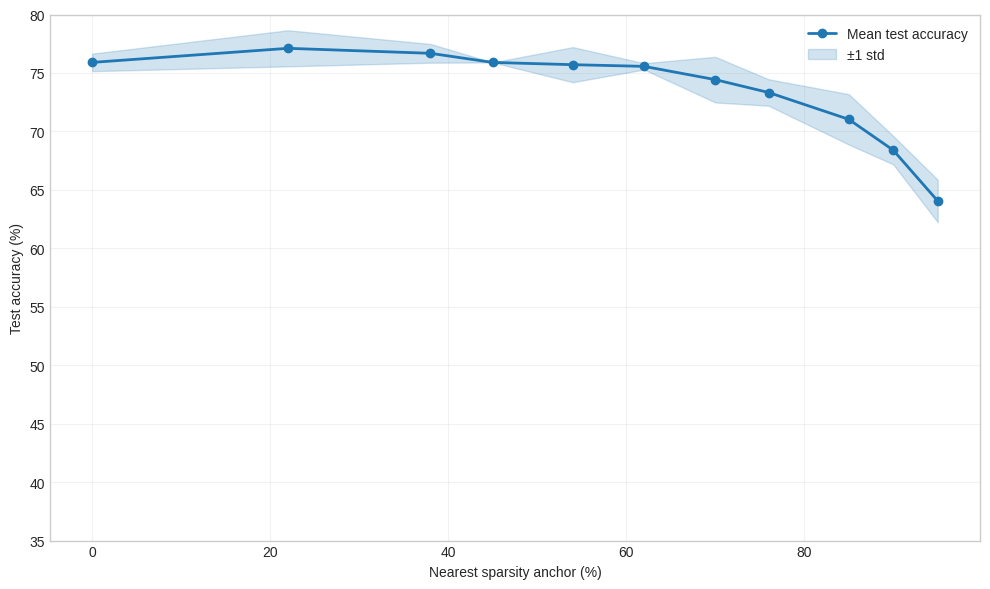

In [ ]:
test_summary = (
    bucketed_summary[["sparsity_bucket", "test_accuracy_mean", "test_accuracy_std"]]
    .dropna(subset=["sparsity_bucket"])
    .sort_values("sparsity_bucket")
    .reset_index(drop=True)
)

x_values = test_summary["sparsity_bucket"].to_numpy()
mean_values = test_summary["test_accuracy_mean"].to_numpy()
std_values = test_summary["test_accuracy_std"].fillna(0).to_numpy()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_values, mean_values, color="tab:blue", marker="o", linewidth=2, label="Mean test accuracy")
ax.fill_between(x_values, mean_values - std_values, mean_values + std_values, color="tab:blue", alpha=0.2, label="\u00b11 std")
#ax.set_title("Test accuracy by nearest sparsity anchor")
ax.set_xlabel("Nearest sparsity anchor (%)")
ax.set_ylabel("Test accuracy (%)")
ax.set_ylim(35, 78)
ax.legend(frameon=False)
ax.grid(alpha=0.25)
fig.tight_layout()

In [21]:
fab_summary = (
    bucketed_summary[["sparsity_bucket", "fab_norm_mean", "fab_norm_std"]]
    .dropna(subset=["sparsity_bucket"])
    .sort_values("sparsity_bucket")
    .reset_index(drop=True)
)

fab_summary

,sparsity_bucket,fab_norm_mean,fab_norm_std
0,0.0,0.120991,0.016296
1,22.0,0.123494,0.015571
2,38.0,0.104369,0.007291
3,45.0,0.101232,NaN
4,54.0,0.095255,0.015834
5,62.0,0.095074,0.015690
6,70.0,0.085692,0.013432
7,76.0,0.080534,0.010885
8,85.0,0.074081,0.011868
9,90.0,0.066261,0.003405


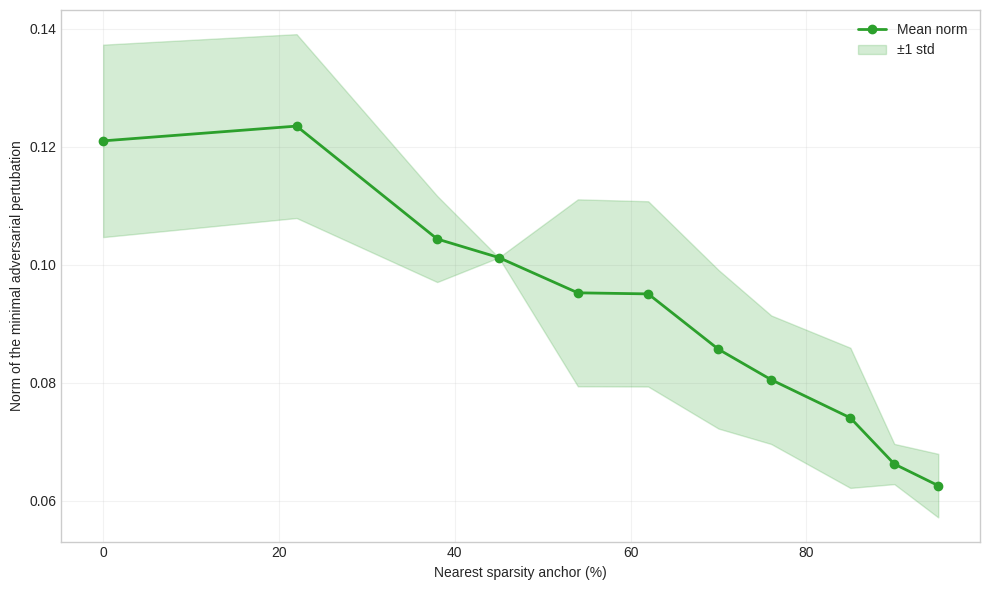

In [22]:
fab_x_values = fab_summary["sparsity_bucket"].to_numpy()
fab_mean_values = fab_summary["fab_norm_mean"].to_numpy()
fab_std_values = fab_summary["fab_norm_std"].fillna(0).to_numpy()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(fab_x_values, fab_mean_values, color="tab:green", marker="o", linewidth=2, label="Mean norm")
ax.fill_between(fab_x_values, fab_mean_values - fab_std_values, fab_mean_values + fab_std_values, color="tab:green", alpha=0.2, label="\u00b11 std")
#ax.set_title("Norm of the minimal adversarial pertubation by nearest sparsity anchor")
ax.set_xlabel("Nearest sparsity anchor (%)")
ax.set_ylabel("Norm of the minimal adversarial pertubation")
ax.legend(frameon=False)
ax.grid(alpha=0.25)
fig.tight_layout()

In [23]:
corruption_category_map = {
    "weather": ["brightness", "fog", "frost", "snow"],
    "noise": ["gaussian_noise", "impulse_noise", "shot_noise", "speckle_noise"],
    "blur": ["defocus_blur", "gaussian_blur", "glass_blur", "motion_blur", "zoom_blur"],
    "digital": ["contrast", "elastic_transform", "jpeg_compression", "pixelate", "saturate", "spatter"],
}

category_error_frame = df.assign(sparsity_bucket=nearest_anchor(df["sparsity"].to_numpy()))
for category, columns in corruption_category_map.items():
    category_error_frame[f"{category}_accuracy"] = 100 - category_error_frame[columns].mean(axis=1)

corruption_category_summary = (
    category_error_frame[
        ["sparsity_bucket", *[f"{category}_accuracy" for category in corruption_category_map]]
    ]
    .groupby("sparsity_bucket", as_index=False)
    .agg(
        **{
            f"{category}_error_mean": (f"{category}_accuracy", "mean")
            for category in corruption_category_map
        },
        **{
            f"{category}_error_std": (f"{category}_accuracy", "std")
            for category in corruption_category_map
        },
    )
    .sort_values("sparsity_bucket")
    .reset_index(drop=True)
)

corruption_category_summary

,sparsity_bucket,weather_error_mean,noise_error_mean,blur_error_mean,digital_error_mean,weather_error_std,noise_error_std,blur_error_std,digital_error_std
0,0.0,65.570300,54.334600,58.463040,65.529400,1.767552,3.279423,1.796423,0.658064
1,22.0,65.150300,54.378000,57.610160,64.297933,2.470619,3.935733,3.377118,1.753079
2,38.0,64.030800,52.968400,55.773040,63.522400,1.663132,3.733339,2.758883,1.068528
3,45.0,63.596500,46.526000,55.697600,63.920667,NaN,NaN,NaN,NaN
4,54.0,63.229000,49.166200,56.247680,63.447267,2.006234,7.599051,2.560039,1.334345
5,62.0,61.864100,47.582700,56.219360,63.008467,1.093364,7.046890,1.607746,0.600248
6,70.0,61.449500,47.675700,54.441440,62.221067,3.348940,6.782738,1.713096,2.407622
7,76.0,59.816100,45.739500,53.830880,61.055200,1.950833,7.122693,2.661475,1.525193
8,85.0,57.459125,44.295000,52.701750,59.134500,2.533839,6.420179,2.286588,1.646819
9,90.0,55.293667,40.261667,51.397867,57.075111,0.685130,5.929278,3.023664,0.647786


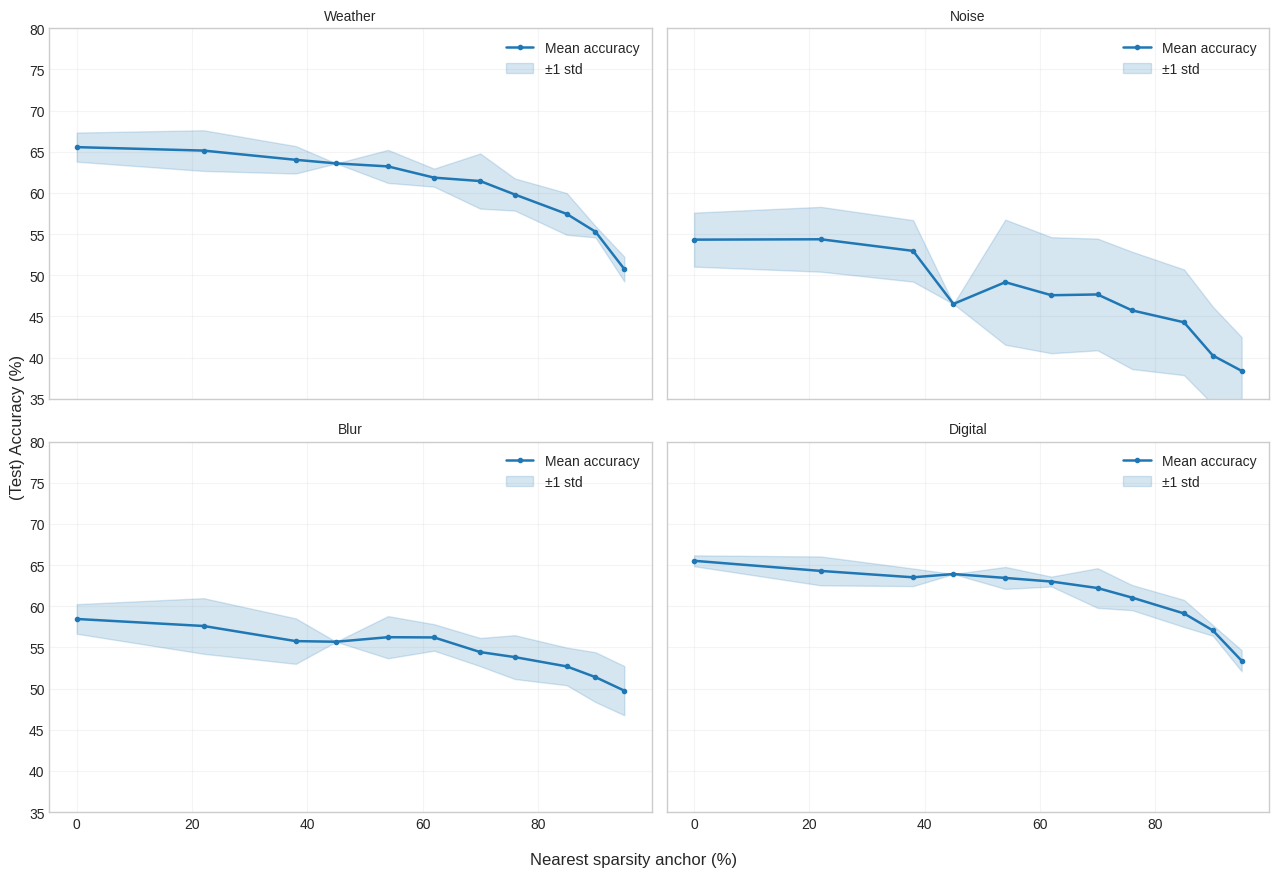

In [37]:
n_cols = 2
n_rows = (len(corruption_category_map) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 9), sharex=True, sharey=True)
axes = axes.flatten()

sparsity_values = corruption_category_summary["sparsity_bucket"].to_numpy()

for axis, category in zip(axes, corruption_category_map):
    mean_column = f"{category}_error_mean"
    std_column = f"{category}_error_std"
    mean_values = corruption_category_summary[mean_column].to_numpy()
    std_values = corruption_category_summary[std_column].fillna(0).to_numpy()

    axis.plot(sparsity_values, mean_values, linewidth=1.8, marker="o", markersize=3, label="Mean accuracy")
    axis.fill_between(sparsity_values, mean_values - std_values, mean_values + std_values, alpha=0.18, label="\u00b11 std", color="tab:blue")
    axis.set_title(category.title(), fontsize=10)
    #axis.legend([f"Mean accuracy"], frameon=False, fontsize=8)
    #axis.legend([f"\u00b11 std"], frameon=False, fontsize=8)
    axis.set_ylim(35, 80)
    axis.grid(alpha=0.2)
    axis.legend(frameon=False)

for axis in axes[len(corruption_category_map):]:
    axis.axis("off")

#fig.suptitle("Accuracy on CIFAR-10-C per corruption type", y=0.995)
fig.supxlabel("Nearest sparsity anchor (%)")
fig.supylabel("(Test) Accuracy (%)")
fig.tight_layout(rect=[0, 0, 1, 0.98])

## Fourier sensitivity

In [ ]:
import torch
import torch.fft
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from irwl1.model import ResNet20
from pathlib import Path
from irwl1.utils import init_mask
from irwl1.regularization import L1_penalty_init

def _load_model_from_checkpoint(checkpoint_path: Path, device: torch.device) -> tuple[torch.nn.Module, dict]:
	model = ResNet20().to(device)
	L1_penalty_init(model)
	init_mask(model)
	checkpoint = torch.load(checkpoint_path, map_location=device)
	state_dict = checkpoint.get("model_state_dict", checkpoint) if isinstance(checkpoint, dict) else checkpoint
	model.load_state_dict(state_dict)
	return model, checkpoint if isinstance(checkpoint, dict) else {}

def generate_fourier_basis(height, width):
    """
    Generates the complete set of 2D Discrete Fourier transform basis matrices
    for a given image canvas size.
    """
    basis_matrices = torch.zeros((height, width, height, width))
    
    for i in range(height):
        for j in range(width):
            # Create a delta impulse in the frequency domain at coordinate (i, j)
            freq_spectrum = torch.zeros((height, width), dtype=torch.complex64)
            freq_spectrum[i, j] = 1.0
            
            # Apply Inverse 2D FFT to convert the frequency delta into a spatial wave
            # We shift the spectrum so low frequencies end up in the center later
            spatial_wave = torch.fft.ifft2(torch.fft.ifftshift(freq_spectrum)).real
            
            # Normalize the basis vector to unit L2 norm
            norm = torch.norm(spatial_wave, p=2)
            if norm > 0:
                spatial_wave /= norm
                
            basis_matrices[i, j] = spatial_wave
            
    return basis_matrices

def evaluate_fourier_sensitivity(model, dataloader, device, epsilon=15/255):
    """
    Evaluates the model across every 2D Fourier frequency component.
    """
    model.eval()
    model.to(device)
    
    # Assuming standard CIFAR-10 dimensions (32x32)
    height, width = 32, 32
    basis_set = generate_fourier_basis(height, width).to(device)
    heatmap = np.zeros((height, width))
    
    print("Evaluating Fourier Sensitivity Grid...")
    for i in tqdm(range(height)):
        for j in range(width):
            U_ij = basis_set[i, j]  # Shape: [32, 32]
            
            total_errors = 0
            total_samples = 0
            
            for images, labels in dataloader:
                images, labels = images.to(device), labels.to(device)
                batch_size = images.size(0)
                
                # 1. Sample uniform random signs {-1, 1} for each sample in the batch
                # Shape: [Batch, 1, 1, 1] to match image channels/dimensions
                rand_values = torch.randint(0, 2, (batch_size, 1, 1, 1), device=device)
                rand_signs = rand_values * 2.0 - 1.0
                
                # 2. Scale the basis element by your absolute epsilon budget
                perturbation = rand_signs * epsilon * U_ij.unsqueeze(0).unsqueeze(1)
                
                # 3. Inject noise and clamp to legal image space bounds
                perturbed_images = torch.clamp(images + perturbation, 0.0, 1.0)
                
                # 4. Forward Pass & Tracking Performance Metrics
                with torch.no_grad():
                    outputs = model(perturbed_images)
                    preds = outputs.argmax(dim=1)
                    total_errors += (preds != labels).sum().item()
                    total_samples += batch_size
            
            # Record mean error rate for the specific (i, j) frequency component
            heatmap[i, j] = total_errors / total_samples
            
    return heatmap
import torch
import torch.fft
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

def evaluate_fourier_sensitivity_optimized(model, dataloader, device, epsilon=15/255):
    """
    Highly optimized Fourier Sensitivity Evaluation.
    Evaluates an entire row of frequencies (32) simultaneously using tensor broadcasting.
    """
    model.eval()
    model.to(device)
    
    height, width = 32, 32
    # Generates basis of shape: [32, 32, 32, 32] (height, width, spatial_y, spatial_x)
    basis_set = generate_fourier_basis(height, width).to(device) 
    heatmap = np.zeros((height, width))
    
    print("Evaluating Optimized Fourier Sensitivity Grid...")
    
    # We now only loop 32 times (once per row) instead of 1,024 times!
    for i in tqdm(range(height), desc="Processing Frequency Rows"):
        
        # Extract a full row of frequencies. 
        # F = 32. Shape: [F, spatial_y, spatial_x]
        U_row = basis_set[i] 
        F = U_row.size(0)    
        
        total_errors = torch.zeros(F, device=device)
        total_samples = 0
        
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            B = images.size(0) # Dataloader Batch Size (e.g., 64)
            
            # 1. Generate random signs for the whole batch and all F frequencies
            # Shape: [B, F, 1, 1, 1]
            rand_values = torch.randint(0, 2, (B, F, 1, 1, 1), device=device)
            rand_signs = rand_values * 2.0 - 1.0
            
            # 2. Reshape U_row so it can broadcast with images
            # From [F, H, W] -> [1, F, 1, H, W]
            U_expanded = U_row.unsqueeze(0).unsqueeze(2)
            
            # 3. Calculate perturbation for all B images across all F frequencies
            # Shape: [B, F, 1, H, W]
            perturbation = rand_signs * epsilon * U_expanded
            
            # 4. Add perturbation to images using PyTorch broadcasting magic!
            # images.unsqueeze(1) is [B, 1, C, H, W]
            # perturbation        is [B, F, 1, H, W]
            # Resulting tensor    is [B, F, C, H, W] (Every image paired with every frequency)
            perturbed_images = torch.clamp(images.unsqueeze(1) + perturbation, 0.0, 1.0)
            
            # 5. Flatten the first two dimensions to feed it into the model
            # From [B, F, C, H, W] -> [B * F, C, H, W]
            # If B=64 and F=32, our effective batch size sent to the GPU is 2,048
            flat_perturbed = perturbed_images.view(B * F, 3, height, width)
            
            # 6. Massive parallel forward pass
            with torch.no_grad():
                outputs = model(flat_perturbed) # Shape: [B * F, NumClasses]
            
            # 7. Reshape predictions back to grid format: [B, F]
            preds = outputs.view(B, F, -1).argmax(dim=2) 
            
            # 8. Compare to labels (labels.unsqueeze(1) is [B, 1])
            # Broadcast comparison results in a [B, F] boolean tensor, then sum over the batch
            batch_errors = (preds != labels.unsqueeze(1)).sum(dim=0)
            
            total_errors += batch_errors
            total_samples += B
            
        # Store the error rates for this entire row at once
        heatmap[i, :] = (total_errors / total_samples).cpu().numpy()
            
    return heatmap

# --- Visualization Function ---
def plot_fourier_heatmap(heatmap):
    plt.figure(figsize=(6, 6))
    # We use 'nearest' interpolation to preserve distinct frequency pixel block views
    plt.imshow(heatmap, cmap='jet', interpolation='nearest')
    plt.colorbar(label='Classification Error Rate')
    plt.title('Model Fourier Sensitivity Map\n(Center = Low Freq | Edges = High Freq)')
    plt.xlabel('Horizontal Frequency ($j$)')
    plt.ylabel('Vertical Frequency ($i$)')
    plt.axis('off')
    plt.show()

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from irwl1.data import fetch_cifar10

_, _, test_loader = fetch_cifar10()
model, checkpoint = _load_model_from_checkpoint(Path("models/run_01/checkpoint_00_sparsity_0.00.pth"), device)
heatmap = evaluate_fourier_sensitivity_optimized(model, test_loader, device)


/home/vilmos/Documents/msc/onlab/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Evaluating Optimized Fourier Sensitivity Grid...


Processing Frequency Rows: 100%|██████████| 32/32 [10:55<00:00, 20.47s/it]


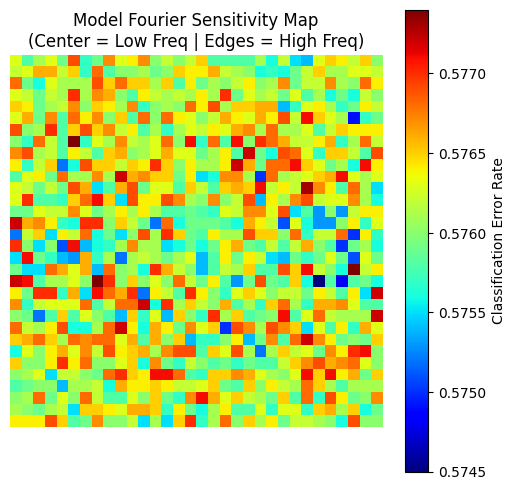

In [ ]:
plot_fourier_heatmap(heatmap)